# LAB 3 — Floating-Base Robot: Quasi-Static Projection Control

The notebook is organized so that **all exercises run from the same controller implementation**. Each experiment only changes a small dictionary of parameters, creates a fresh controller instance, runs the simulation, copies the logs, cleans up the controller, and returns the results for later comparison.

## Exercises included

1. Sinusoidal trunk reference generation
2. Projection-based quasi-static control of the base
3. Gravity compensation
4. Feed-forward compensation
5. CoM control
6. Static stability / support polygon



## Simulation note

Check the controller publishing frequency with

```bash
rostopic hz /command
```

If the desired frequency (i.e. 500 Hz) cannot be maintained, tracking errors may be caused by computation delays rather than by the control law. In case of delays to slow the Gazebo simulation when necessary, reduce XX, where XX = 1000 is Real-time factor

```python
p.startSimulator(additional_args=["gui:=false"])
p.setSimSpeed(dt_sim=lab_conf.dt, max_update_rate=XX)
```

Note that the whole ROS environment will be slowed down with respect to the real world time, so also the controller, so with this trick it should be able to meet the required publishing frequency. For notebook use, we avoid calling `ros.signal_shutdown()` after each experiment because that permanently shuts down `rospy` for the current kernel. Instead, each experiment calls `p.deregister_node()` in its cleanup phase.

## 0. Imports

In [1]:
import copy
import numpy as np
from numpy import nan
import matplotlib.pyplot as plt
import rospy as ros
from scipy.linalg import block_diag
from gazebo_ros import gazebo_interface
from base_controllers.base_controller import BaseController
from base_controllers.components.controlRoutines import projectionBasedController
from base_controllers.utils.common_functions import plotFrame,  plotContacts,  State
import base_controllers.params as conf
import lab_conf

robotName = "aliengo"
np.set_printoptions(precision=4, suppress=True, linewidth=160)

## 1. Reference generation

The lab uses simultaneous sinusoidal references for vertical trunk motion and pitch. The position reference is written as

$
x^d(t)=x_0+A\left[\cos(2\pi f t+\phi)-1\right],
$

so that the initial desired position coincides with the initial robot configuration and the initial desired velocity is zero. Its derivatives are

$
\dot{x}^d(t)=-2\pi fA\sin(2\pi f t+\phi),
$

$
\ddot{x}^d(t)=-(2\pi f)^2A\cos(2\pi f t+\phi).
$

The desired linear motion is defined in a horizontal frame (HF) aligned with the desired yaw and with gravity.
Generate a sinusoidal reference for Z direction ($f_z$ = 0.5 Hz, $A_z$ = 0.03 m) together with another for the pitch direction ($f_{\theta}$ = 1 Hz, $A_{\theta}$ = 0.1 rad). Set frequencies and amplitudes in the lab_conf.py file.

**Important:** in this implementation, for simplicity the angular entries of `des_twist` and `des_acc` contain Euler-angle rates and derivatives of Euler-angle rates. They are not automatically equal to the angular velocity $\omega$ and angular acceleration $\dot{\omega}$ except for small change of orientations w.r.t the horizontal

In [2]:
def generate_sinusoidal_reference(p, exp):
    two_pi_f = 2.0 * np.pi * exp["freq"]
    two_pi_f_amp = two_pi_f * exp["amp"]
    two_pi_f_squared_amp = two_pi_f * two_pi_f_amp

    # the reference pose is defined in the horizontal frame
    ref_pose = p.x0 + exp["amp"] * (np.cos(two_pi_f * p.time + exp["phi"]) - 1.0)
    # we assume the ZYX convention
    des_euler_angles = ref_pose[3:6]

    # extract the yaw and buld the R(yaw) rotation
    w_R_hf = p.math_utils.eul2Rot(np.array([0.0, 0.0, des_euler_angles[2]]))

    p.des_poseW = np.zeros(6)
    # rotate the linear coordinates with the yaw of the robot
    p.des_poseW[0:3] = w_R_hf @ ref_pose[0:3]
    # the angular part remains unchanged because they are Euler angles
    p.des_poseW[3:6] = des_euler_angles

    # the reference twist is defined in the horizontal frame
    ref_twist = -two_pi_f_amp * np.sin(two_pi_f * p.time + exp["phi"])

    p.des_twist = np.zeros(6)
    # rotate the linear coordinates with the yaw of the robot
    p.des_twist[0:3] = w_R_hf @ ref_twist[0:3]
    # the angular part remains unchanged because they are Euler rates
    p.des_twist[3:6] = ref_twist[3:6]

    # the derivative of the reference twist is defined in the horizontal frame
    ref_twist_dot = -two_pi_f_squared_amp * np.cos(two_pi_f * p.time + exp["phi"])

    p.des_acc = np.zeros(6)
    p.des_acc[0:3] = w_R_hf @ ref_twist_dot[0:3]
    p.des_acc[3:6] = ref_twist_dot[3:6]

### Static / quasi-static CoM reference

For the static-stability experiment, the sinusoidal reference is disabled and the desired CoM is slowly shifted horizontally along the Y coordinate:

$
y_{\mathrm{com}}^d(t)=y_{\mathrm{com}}(0)+v_y^d t.
$

In [3]:
def generate_com_reference(p, exp):
    p.des_poseW = np.copy(p.x0)
    p.des_poseW[p.u.sp_crd["LY"]] += exp["com_velocity_y"] * float(p.time)

    p.des_twist = np.zeros(6)
    p.des_twist[p.u.sp_crd["LY"]] = exp["com_velocity_y"]

    p.des_acc = np.zeros(6)

## 2. Projection-based quasi-static controller

We design a controller for the base frame position and orientation with a projection-based approach. First the feedback wrench $W_{\mathrm{fbk,lin}} \in \mathcal{R}^6$ is computed by a virtual impedance to track the references generated in 1) for the _base_ frame position and orientation.

$
W_{\mathrm{fbk,lin}}^d = K_{\mathrm{lin}}(x_b^d-x_b)+D_{\mathrm{lin}}(\dot{x}_b^d-\dot{x}),
$

$
W_{\mathrm{fbk,ang}}^d = -K_{\mathrm{ang}}e_o + D_{\mathrm{ang}}(\omega_b^d-\omega).
$

where $e_o \in \mathcal{R}^3$ is the orientation error.

Now we want to map this desired wrench into joint torques (quasi-static assumption). For $c$ stance contacts,

$
W^d = J_c^T f^d,
$

with, for a wrench expressed about the base origin, with quasi-static assumption we have

$
f^d=(J_{c,b}^T)^\dagger W^d,
$

where

$
J_{cb}^T =
\begin{bmatrix}
I & \cdots & I\\
[x_{f_1}-x_b]_\times & \cdots & [x_{f_c}-x_b]_\times
\end{bmatrix}.
$

and

$
\tau^d=-J_{cj}^T f^d.
$

Note that $W = J_c^T f$ represents the contact wrench that is given as input to the Newton-Euler equations, but we are doing an approximation here: we are controlling the orientation of the base link rather than an equivalent rigid body whose angular velocity $\bar{\omega}$̄ is the average angular velocity of all the links of the robot (as Newton-Euler equations state). In essence we are approximating $\bar{\omega}$ with $\omega_b$.


## Common controller code

In [4]:
des_state = State(desired=True)
act_state = State()

In [5]:
class AdvancedController(BaseController):
    def __init__(self, robot_name="aliengo"):
        super().__init__(robot_name=robot_name)

    def initVars(self):
        super().initVars()
        buffer_size = conf.robot_params[self.robot_name]["buffer_size"]

        self.des_PoseW_log = np.empty((6, buffer_size)) * nan
        self.des_Twist_log = np.empty((6, buffer_size)) * nan
        self.des_Acc_log = np.empty((6, buffer_size)) * nan
        self.des_forcesW_log = np.empty((12, buffer_size)) * nan
        self.comPoseW_log = np.empty((6, buffer_size)) * nan
        self.Wffwd_log = np.empty((6, buffer_size)) * nan
        self.Wfbk_log = np.empty((6, buffer_size)) * nan
        self.Wg_log = np.empty((6, buffer_size)) * nan

        self.params = lab_conf.Params()
        self.stop_requested = False

    def logData(self):
        if self.log_counter < conf.robot_params[self.robot_name]["buffer_size"]:
            self.des_PoseW_log[:, self.log_counter] = self.des_poseW
            self.des_Twist_log[:, self.log_counter] = self.des_twist
            self.des_Acc_log[:, self.log_counter] = self.des_acc
            self.comPoseW_log[:, self.log_counter] = self.comPoseW
            self.des_forcesW_log[:, self.log_counter] = self.des_forcesW
            self.Wffwd_log[:, self.log_counter] = self.Wffwd
            self.Wfbk_log[:, self.log_counter] = self.Wfbk
            self.Wg_log[:, self.log_counter] = self.Wg

        super().logData()

    def resetRobot(self, basePoseDes=None, baseTwistDes=None):
        # teleport back to nominal standing pose so the previous experiment's end state doesn't carry over
        if basePoseDes is None:
            basePoseDes = self.base_offset.copy()
        if baseTwistDes is None:
            baseTwistDes = np.zeros(6)

        self.q_des = conf.robot_params[self.robot_name]['q_0']
        self.qd_des = np.zeros(len(self.joint_names))
        self.tau_ffwd = np.zeros(len(self.joint_names))

        self.pid.setPDjoints(conf.robot_params[self.robot_name]['kp'],
                              conf.robot_params[self.robot_name]['kd'],
                              np.zeros(len(self.joint_names)))

        # freeze gravity while teleporting so the robot cannot start falling mid-reset
        self.freezeBase(True, basePoseW=basePoseDes, baseTwistW=baseTwistDes)
        gazebo_interface.set_model_configuration_client(self.robot_name, '', self.joint_names, self.q_des, '/gazebo')
        self.send_des_jstate(self.q_des, self.qd_des, self.tau_ffwd)
        self.freezeBase(False, basePoseW=basePoseDes, baseTwistW=baseTwistDes)

        # settle onto the ground under joint PD before handing control to the virtual-model
        # controller, same as startupProcedure() does on the very first spawn. Without this,
        # the legs/contacts haven't loaded yet when the next experiment's zero-PD tracking
        # loop starts, producing a large initial transient.
        start_t = ros.get_time()
        while ros.get_time() - start_t < 0.5:
            self.send_des_jstate(self.q_des, self.qd_des, self.tau_ffwd)
            ros.sleep(0.01)

        self.updateKinematics()

In [6]:
def select_control_point(p, exp):
    # com offset
    p.params.W_base_to_com = p.u.linPart(p.comPoseW) - p.u.linPart(p.basePoseW)

    # Exercise 5 model-error test
    p.params.W_base_to_com[0] += exp["com_offset_error_x"]

    p.params.robot = p.robot

    if not exp["is_com_controlled"]:
        act_state.pose.set(p.basePoseW)
        act_state.twist.set(p.baseTwistW)
        p.params.robotInertiaB = p.centroidalInertiaB
    else:
        act_state.pose.set(p.comPoseW)
        act_state.twist.set(p.comTwistW)
        p.params.robotInertiaB = p.compositeRobotInertiaB

In [7]:
def compute_contact_forces(p, exp):
    p.params.gravityComp = exp["gravity_comp"]
    p.params.ffwdOn = exp["feedforward"]

    if exp["feedforward"] and exp["ffwd_ramp_time"] > 0:
        # des_acc starts at its peak amplitude at t=0 (position/velocity error are zero there,
        # but the cosine-based reference's acceleration is not), so feeding it straight into the
        # feed-forward term injects an instantaneous jerk on a robot that is still at rest. Ramp
        # the acceleration used for the feed-forward term in linearly instead of gating it on/off.
        ramp = min(1.0, float(p.time) / exp["ffwd_ramp_time"])
        des_state.accel.set(ramp * p.des_acc)

    p.des_forcesW, p.Wffwd,  p.Wfbk, p.Wg  = projectionBasedController(lab_conf.control_params[p.robot_name],  act_state, des_state, p.W_contacts, p.stance_legs, p.params)

### Map Contact forces into joint torques

$
\tau_{\mathrm{ffwd}} = h_j-J_{cj}^T f^d.
$

In [8]:
def contact_forces_to_joint_torques(p):
    p.jacsT = block_diag(p.wJ[p.u.leg_map["LF"]].T,
                        p.wJ[p.u.leg_map["LH"]].T,
                        p.wJ[p.u.leg_map["RF"]].T,
                        p.wJ[p.u.leg_map["RH"]].T)
    p.tau_ffwd = p.h_joints - p.jacsT @ p.des_forcesW

## Generic simulation loop

In [9]:
def prepare_experiment(p, exp):
    # Reset robot to nominal standing pose and reset logs/experiment variables
    p.resetRobot()
    p.initVars()
    p.params.isCoMControlled = exp["is_com_controlled"]
    p.updateKinematics()
    if exp["is_com_controlled"]:
        p.x0 = np.copy(p.comPoseW)
    else:
        p.x0 = np.copy(p.basePoseW)
    # ensure joint PDs are zero to avoid conflict with constant joint trajectories (we do not update them!)
    p.pid.setPDs(0.0, 0.0, 0.0)
    p.time = 0.0
    p.log_counter = 0
    p.stop_requested = False

def run_control_loop(p, exp):
    # control loop frequency
    rate = ros.Rate(1.0 / lab_conf.dt)

    # Control loop
    while (not p.stop_requested and p.time < exp["duration"]   and not ros.is_shutdown()):
        p.updateKinematics()

        if exp["use_sinusoid"]:
            generate_sinusoidal_reference(p, exp)
        else:
            generate_com_reference(p, exp)

        des_state.pose.set(p.des_poseW)
        des_state.twist.set(p.des_twist)
        des_state.accel.set(p.des_acc)
        #chose if to control base or com
        select_control_point(p, exp)
        compute_contact_forces(p, exp)
        contact_forces_to_joint_torques(p)
        # send fftd torques commands to Simulator
        p.send_des_jstate(p.q_des, p.qd_des, p.tau_ffwd)
        # log variables
        p.logData()
        # update loop time
        p.time = np.round(p.time + np.array([conf.robot_params[p.robot_name]["dt"]]), 3)
        # plot contact forces (accumulate all 4 legs' arrows before publishing once, otherwise
        # each publishVisual() call resets the marker ids and overwrites the previous leg's arrows)
        for leg in range(4):
            p.ros_pub.add_arrow(p.W_contacts[leg], p.u.getLegJointState(leg, p.grForcesW / (5 * p.robot.robotMass)), "green")
            p.ros_pub.add_arrow(p.W_contacts[leg], p.u.getLegJointState(leg, p.des_forcesW / (5 * p.robot.robotMass)),"blue")
        p.ros_pub.publishVisual(delete_markers=False)
        # wait for synconization of the control loop
        rate.sleep()

## Experiment configuration


In [10]:
def make_experiment(name,
    is_com_controlled=False,
    gravity_comp=False,
    feedforward=False,
    duration=None,
    use_sinusoid=True,
    amp=None,
    freq=None,
    phi=None,
    com_velocity_y=0.0,
    com_offset_error_x=0.0,
    ffwd_ramp_time=1.0,
):
    if duration is None:
        duration = float(lab_conf.exp_duration)
    if amp is None:
        amp = np.copy(lab_conf.amp)
    if freq is None:
        freq = np.copy(lab_conf.freq)
    if phi is None:
        phi = np.copy(lab_conf.phi)

    return {
        "name": name,
        "is_com_controlled": is_com_controlled,
        "gravity_comp": gravity_comp,
        "feedforward": feedforward,
        "duration": duration,
        "use_sinusoid": use_sinusoid,
        "amp": np.array(amp, dtype=float),
        "freq": np.array(freq, dtype=float),
        "phi": np.array(phi, dtype=float),
        "com_velocity_y": float(com_velocity_y),
        "com_offset_error_x": float(com_offset_error_x),
        "ffwd_ramp_time": float(ffwd_ramp_time),
    }

## Experiment definitions

In [11]:
EX2 = make_experiment(
    name="Exercise 2 - base feedback only",
    is_com_controlled=False,
    gravity_comp=False,
    feedforward=False)

EX3 = make_experiment(
    name="Exercise 3 - base + gravity compensation",
    is_com_controlled=False,
    gravity_comp=True,
    feedforward=False)

EX4 = make_experiment(
    name="Exercise 4 - base + gravity + feed-forward",
    is_com_controlled=False,
    gravity_comp=True,
    feedforward=True,
)

EX5 = make_experiment(
    name="Exercise 5 - CoM control + gravity + feed-forward",
    is_com_controlled=True,
    gravity_comp=True,
    feedforward=False,
)

EX5_ERROR = make_experiment(
    name="Exercise 5 - CoM control with 5 cm model error + gravity + feed-forward",
    is_com_controlled=True,
    gravity_comp=True,
    feedforward=False,
    com_offset_error_x=0.05,
)

EX6 = make_experiment(
    name="Exercise 6 - static stability",
    is_com_controlled=True,
    gravity_comp=True,
    feedforward=False,
    use_sinusoid=False,
    com_velocity_y=-0.04,
    duration=8.0,
)

## Copy the logs  and plot results

Each run returns copied NumPy arrays instead of the complete ROS controller object.

In [12]:
def collect_results(p, exp):
    n = int(p.log_counter)
    return {
        "config": copy.deepcopy(exp),
        "time": np.copy(p.time_log[:n]),
        "des_pose": np.copy(p.des_PoseW_log[:, :n]),
        "base_pose": np.copy(p.basePoseW_log[:, :n]),
        "com_pose": np.copy(p.comPoseW_log[:, :n]),
        "des_twist": np.copy(p.des_Twist_log[:, :n]),
        "des_acc": np.copy(p.des_Acc_log[:, :n]),
        "des_forces": np.copy(p.des_forcesW_log[:, :n]),
        "gr_forces": np.copy(p.grForcesW_log[:, :n]),
        "Wfbk": np.copy(p.Wfbk_log[:, :n]),
        "Wg": np.copy(p.Wg_log[:, :n]),
        "Wffwd": np.copy(p.Wffwd_log[:, :n]),
    }

In [13]:
def plot_result(result, controlled_point="base", plots=("position", "acceleration", "velocity", "wrench", "grf")):
    if not lab_conf.plotting:
        return
    cfg = result["config"]

        # remember figures that already existed
    old_figs = set(plt.get_fignums())

    if "position" in plots:
        if not cfg["is_com_controlled"]:
            plotFrame(
                'position',
                time_log=result["time"],
                des_Pose_log=result["des_pose"],
                Pose_log=result["base_pose"],
                title='base lin/ang position',
                frame='W',
                sharex=True,
                sharey=False,
                start=0,
                end=-1
            )
        else:
            plotFrame(
                'position',
                time_log=result["time"],
                des_Pose_log=result["des_pose"],
                Pose_log=result["com_pose"],
                title='com lin/ang position',
                frame='W',
                sharex=True,
                sharey=False,
                start=0,
                end=-1
            )

    if "acceleration" in plots:
        # desired acceleration
        plotFrame(
            'acceleration',
            time_log=result["time"],
            Acc_log=result["des_acc"],
            title='acceleration',
            frame='W',
            sharex=True,
            sharey=False,
            start=0,
            end=-1
        )

    if "velocity" in plots:
        # desired velocity
        plotFrame(
            'velocity',
            time_log=result["time"],
            Twist_log=result["des_twist"],
            title='velocity',
            frame='W',
            sharex=True,
            sharey=False,
            start=0,
            end=-1
        )

    if "wrench" in plots:
        # feed-forward wrench (blue) vs feedback wrench (red) so the two contributions can be compared directly
        plotFrame(
            'wrench',
            time_log=result["time"],
            Wrench_log=result["Wg"] + result["Wfbk"] + result["Wffwd"],
            title='wrench (red=ffwd, blue=feedback)',
            frame='W',
            sharex=True,
            sharey=False,
            start=0,
            end=-1
        )

    if "grf" in plots:
        # ground reaction forces
        plotContacts(
            'GRFs',
            time_log=result["time"],
            des_Forces_log=result["des_forces"],
            Forces_log=result["gr_forces"],
            frame='W',
            sharex=True,
            sharey=False,
            start=0,
            end=-1
        )
    # ------------------------------------------------------
    # FORCE JUPYTER TO RENDER THE FIGURES NOW
    # ------------------------------------------------------

    new_figs = [
        n for n in plt.get_fignums()
        if n not in old_figs
    ]

    for n in new_figs:
        fig = plt.figure(n)
        display(fig)

## Generic experiment runner

`run_experiment()` creates a fresh controller for every run, copies the logs, then deregisters the controller. It does not call `ros.signal_shutdown()`, so another experiment can be launched in the same Jupyter kernel.

In [14]:
def run_experiment(p, exp):
    print("=" * 72)
    print(exp["name"])
    print("=" * 72)
    prepare_experiment(p, exp)
    try:
        run_control_loop(p, exp)
    except KeyboardInterrupt:
        print("\nExperiment interrupted by user.")
    data = collect_results(p, exp)
    print("Experiment finished")
    return data

# Exercise 2 — Closing the loop on Base Frame (Feedback only)

Design a controller for the base frame position and orientation with a projection-based approach
$
W^d=W_{\mathrm{fbk}}.
$
Check the robot is tracking the sinusoidal reference trajectory of point 1). See that without compensating gravity the robot is barely able to stand-up accumulating huge errors on the Z direction. Observe the vertical steady-state error when gravity is not compensated.

Initialized basecontroller---------------------------------------------------------------
... logging to /root/.ros/log/a235ce3c-b1f0-11f1-b72a-ac50defed81d/roslaunch-docker-30050.log


sh: 1: killall: not found


started roslaunch server http://docker:45419/

SUMMARY

PARAMETERS
 * /aliengo/joint_state_publisher/publish_rate: 500
 * /aliengo/joint_state_publisher/type: joint_state_contr...
 * /aliengo/ros_impedance_controller/gains/lf_haa_joint/d: 0.2
 * /aliengo/ros_impedance_controller/gains/lf_haa_joint/i: 0.0
 * /aliengo/ros_impedance_controller/gains/lf_haa_joint/p: 3.0
 * /aliengo/ros_impedance_controller/gains/lf_hfe_joint/d: 0.2
 * /aliengo/ros_impedance_controller/gains/lf_hfe_joint/i: 0.0
 * /aliengo/ros_impedance_controller/gains/lf_hfe_joint/p: 3.0
 * /aliengo/ros_impedance_controller/gains/lf_kfe_joint/d: 0.2
 * /aliengo/ros_impedance_controller/gains/lf_kfe_joint/i: 0.0
 * /aliengo/ros_impedance_controller/gains/lf_kfe_joint/p: 3.0
 * /aliengo/ros_impedance_controller/gains/lh_haa_joint/d: 0.2
 * /aliengo/ros_impedance_controller/gains/lh_haa_joint/i: 0.0
 * /aliengo/ros_impedance_controller/gains/lh_haa_joint/p: 3.0
 * /aliengo/ros_impedance_controller/gains/lh_hfe_joint/d: 0.2
 

libGL error: failed to create dri screen
libGL error: failed to load driver: nouveau
libGL error: failed to create dri screen
libGL error: failed to load driver: nouveau
Gazebo multi-robot simulator, version 11.15.1
Copyright (C) 2012 Open Source Robotics Foundation.
Released under the Apache 2 License.
http://gazebosim.org

libGL error: failed to create dri screen
libGL error: failed to load driver: nouveau


SIMULATION Started
URDF generated_commons
Starting ros pub---------------------------------------------------------------


[Err] [Plugin.hh:212] Failed to load plugin libset_mass_plugin.so: libset_mass_plugin.so: cannot open shared object file: No such file or directory
[Err] [Plugin.hh:212] Failed to load plugin libset_damping_plugin.so: libset_damping_plugin.so: cannot open shared object file: No such file or directory


[INFO] [1789578250.994400649]: Finished loading Gazebo ROS API Plugin.
[INFO] [1789578250.995230485]: waitForService: Service [/gazebo/set_physics_properties] has not been advertised, waiting...
[Msg] Waiting for master.
[Msg] Connected to gazebo master @ http://127.0.0.1:11345
[Msg] Publicized address: 10.196.225.39
[Msg] Loading world file [/root/ros_ws/install/share/ros_impedance_controller/worlds/solo.world]
[INFO] [1789578251.261407468]: waitForService: Service [/gazebo/set_physics_properties] is now available.
[INFO] [1789578251.272587043]: Physics dynamic reconfigure ready.
[INFO] [1789578251.770850810]: <initialOrientationAsReference> is unset, using default value of false to comply with REP 145 (world as orientation reference)
[INFO] [1789578251.770890734]: <robotNamespace> set to: //
[INFO] [1789578251.770899651]: <topicName> set to: aliengo/trunk_imu
[INFO] [1789578251.770905071]: <frameName> set to: trunk_imu
[INFO] [1789578251.770921161]: <updateRateHZ> set to: 500
[INFO] 

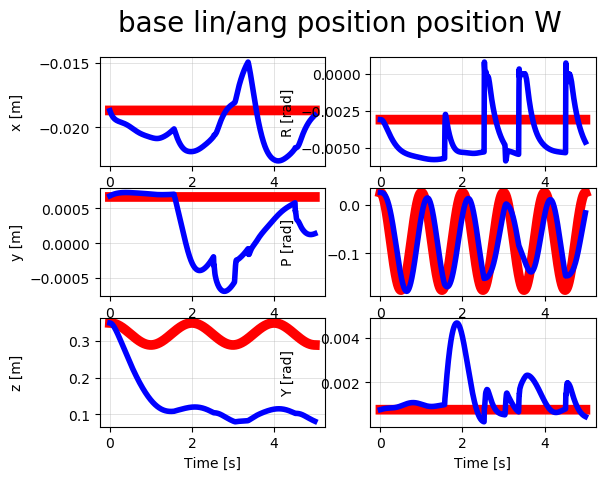

In [15]:
p = AdvancedController(robotName)
p.start()
p.startSimulator(additional_args=["gui:=false"])
p.loadModelAndPublishers()
p.initVars()
p.initSubscribers()
p.startupProcedure()
p.updateKinematics()
p.setSimSpeed(dt_sim=lab_conf.dt, max_update_rate=300)
print("ROS environment initialized")

results = {}
results["ex2"] = run_experiment(p, EX2)
plot_result(results["ex2"],  plots=("position"))

# Exercise 3 — Gravity compensation

Add a gravity term to the desired wrench $W^d$

$
W^d=W_{\mathrm{fbk}}+W_g.
$

Remember that gravity is applied to CoM). Therefore some changes are necessary if we close the loop at the base frame origin,

$
W_g=\begin{bmatrix}mg\\x_{b,\mathrm{com}}\times mg\end{bmatrix}.
$

How is the tracking error in steady state? and in motion? Play with the frequency of the controller (e.g. check parameter dt in lab_conf) affects the maximum damping (e.g. Kd_lin in lab_conf) the system can tolerate (without being unstable),  higher damping values are achievable for higher loop frequencies.

Exercise 3 - base + gravity compensation
Freezing base
Freezing base
Experiment finished


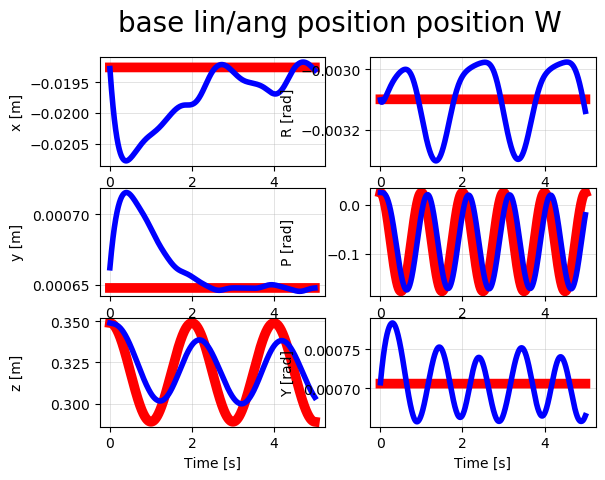

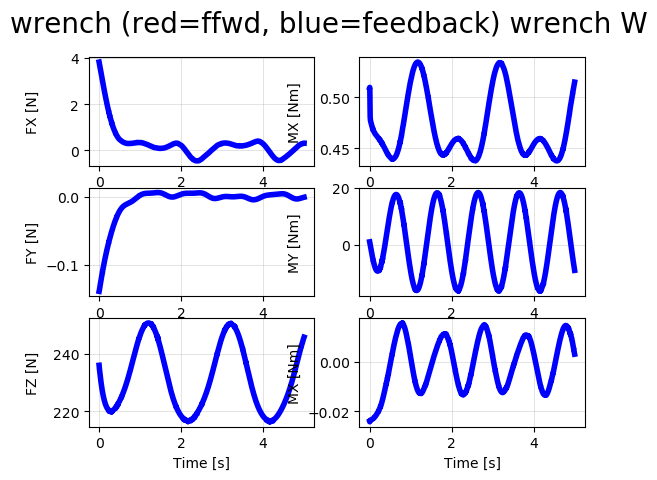

In [16]:
results["ex3"] = run_experiment(p, EX3)
plot_result(results["ex3"],  plots=("position", "wrench"))

# Exercise 4 — Feed-forward

Add a feed-forward term the desired wrench $W^d$. A feed-forward action relieve the effort of the feed-back action and enables to track better time-varying references. Check the implementation inside the Class **ProjectionBasedController** (hint: exploit the mass matrix and the tensor of inertia). Be sure that at the angular level you use $\dot{\omega}^d$ and not $\ddot{\Phi}^d$. Should we ramp in desired acceleration? why?

$
W^d=W_{\mathrm{fbk}}+W_g+W_{\mathrm{ffwd}}.
$

In [17]:
#results["ex4"] = run_experiment(p, EX4)
#plot_result(results["ex4"], plots=("position"))

# Exercise 5 — CoM control

When the wrench is expressed about the CoM,

$
W_g=\begin{bmatrix}mg\\0\end{bmatrix}.
$

**Note** you cannot control both pitch and Z and expect 0 error on the X component of com, only on base, because it is an impossible task, being the com not exactly in the baricentrum of the trunk (not true for aliengo robot that is asymmetric), hence a pitch motion of the trunk always involves X motion of the com.

Exercise 5 - CoM control + gravity + feed-forward
Freezing base
Freezing base
Experiment finished


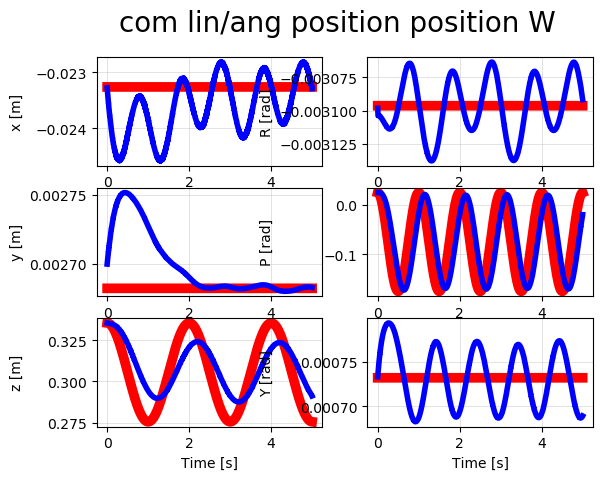

In [18]:
results["ex5"] = run_experiment(p, EX5)
plot_result(results["ex5"], plots=("position"))

## Exercise 5b — 5 cm CoM model error

Exercise 5 - CoM control with 5 cm model error + gravity + feed-forward
Freezing base
Freezing base
Experiment finished


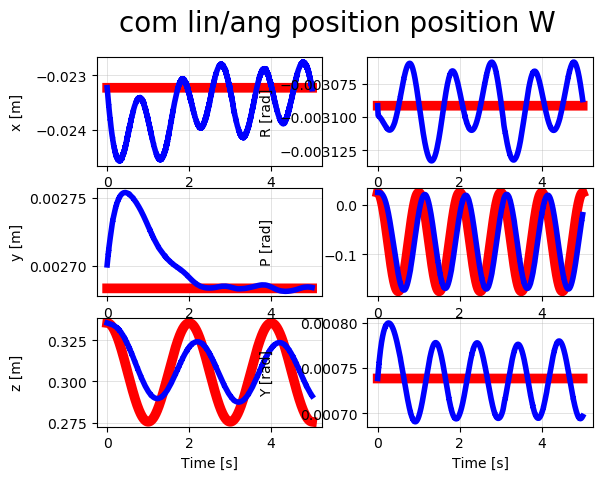

In [19]:
results["ex5_error"] = run_experiment(p, EX5_ERROR)
plot_result(results["ex5_error"], plots=("position"))

# Exercise 6 — Static stability

Move the CoM slowly toward the edge of the support polygon and inspect the desired normal contact forces.  This highlights the limits of the projectionBasedController has no way to say "no" and maps the total wrench to ground-reaction forces with a plain pseudoinverse $f^d=(J_{c,b}^T)^\dagger W^d$.
There's nothing stopping this from returning a negative normal force for some leg (i.e. "pull down on the ground") — physically impossible for a real unilateral contact. When a leg's commanded Fz toward (or past) zero,
the simulated robot can't actually deliver the commanded force (it can only push, not pull), so the real GRF diverges from the commanded GRF — you get force saturation, and we have not a clean linear tracking system anymore.

Exercise 6 - static stability
Freezing base
Freezing base
Experiment finished


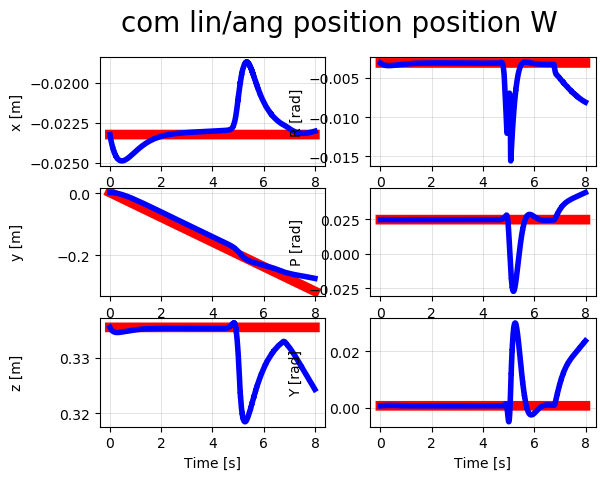

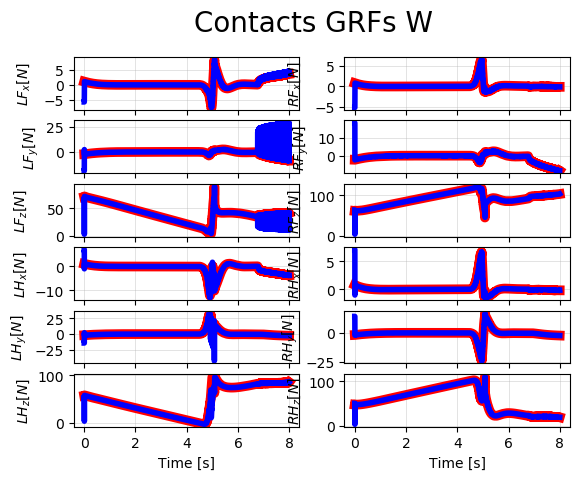

In [20]:
results["ex6"] = run_experiment(p, EX6)
plot_result(results["ex6"], plots=("position", "grf"))

## Discussion questions

1. Why does feedback-only control produce a large steady-state error in the vertical direction?
2. Why does gravity compensation about the base origin require a moment term?
3. Why does that gravity moment disappear when the wrench is expressed about the CoM?
4. What improvement does the feed-forward wrench provide during motion?
5. How sensitive is CoM control to an error in the estimated base-to-CoM offset?
6. What happens to the desired vertical contact forces as the CoM approaches the support-polygon boundary?
7. Why can the pseudoinverse force distribution produce negative normal forces?